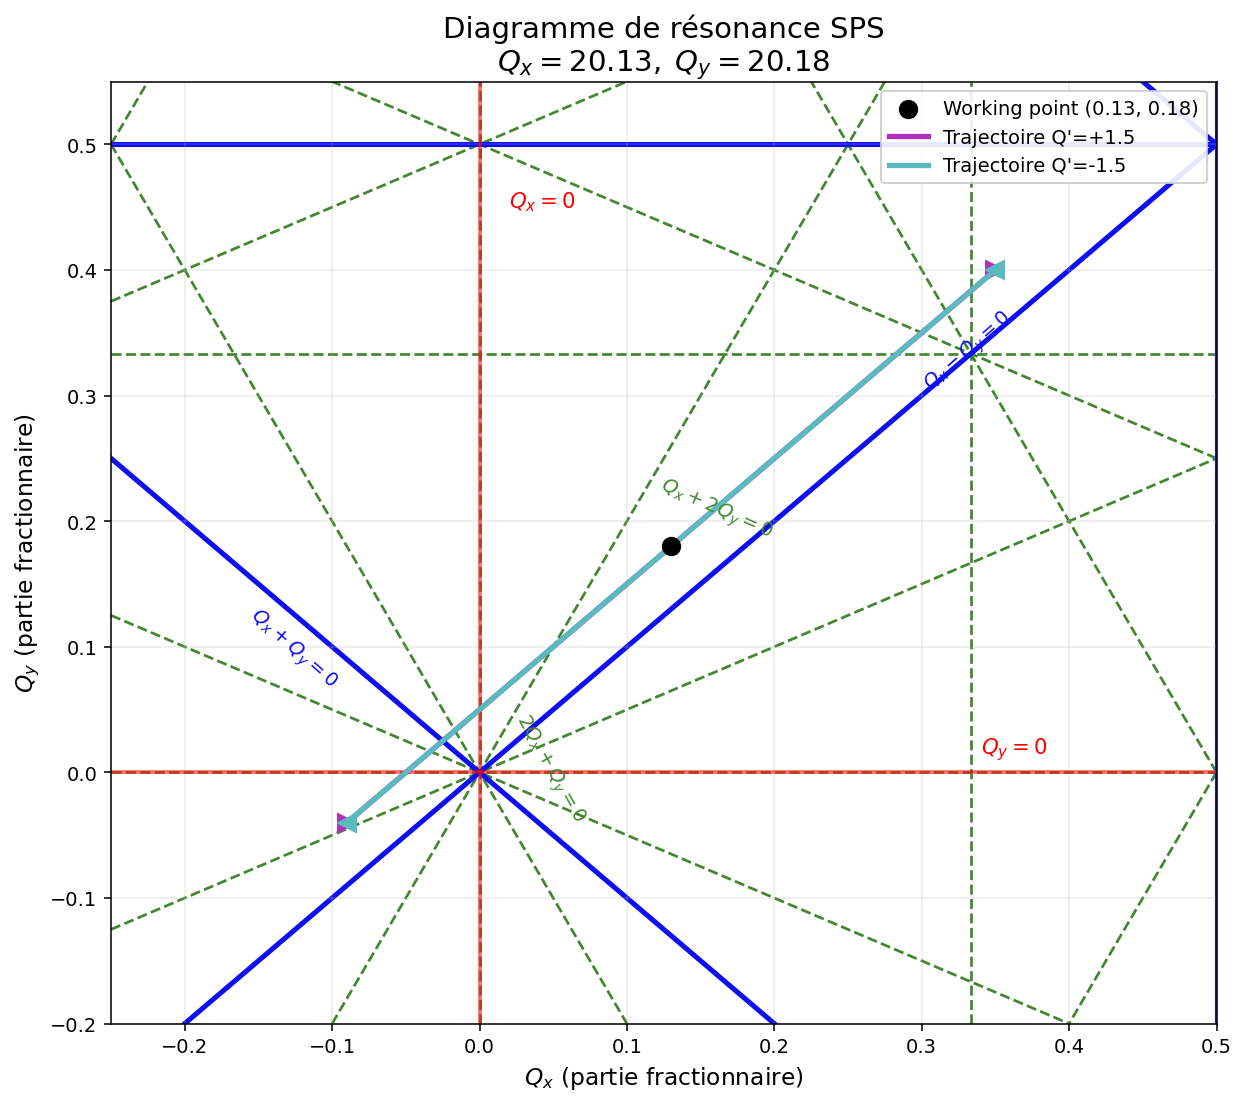

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from math import gcd

# --- colors close to your screenshot ---
C_BLUE   = "#0E0EF4"
C_GREEN  = "#42872F"
C_RED    = "#FF0000"
C_PURPLE = "#B22FBC"
C_CYAN   = "#5ABAC0"

def _gcd3(a, b, c):
    return gcd(gcd(abs(a), abs(b)), abs(c))

def _normalize_mnp(m, n, p):
    g = _gcd3(m, n, p)
    if g > 1:
        m, n, p = m // g, n // g, p // g
    if m < 0 or (m == 0 and n < 0):
        m, n, p = -m, -n, -p
    return m, n, p

def _clip_line_to_rect(m, n, p, xlim, ylim, tol=1e-12):
    xmin, xmax = xlim
    ymin, ymax = ylim
    pts = []

    if abs(n) > tol:
        for x in (xmin, xmax):
            y = (p - m * x) / n
            if ymin - tol <= y <= ymax + tol:
                pts.append((x, y))

    if abs(m) > tol:
        for y in (ymin, ymax):
            x = (p - n * y) / m
            if xmin - tol <= x <= xmax + tol:
                pts.append((x, y))

    uniq = []
    for x, y in pts:
        if not any(abs(x-xu) < 1e-9 and abs(y-yu) < 1e-9 for xu, yu in uniq):
            uniq.append((x, y))
    if len(uniq) < 2:
        return None

    # farthest pair
    best = None
    dmax = -1.0
    for i in range(len(uniq)):
        for j in range(i+1, len(uniq)):
            dx = uniq[i][0] - uniq[j][0]
            dy = uniq[i][1] - uniq[j][1]
            d = dx*dx + dy*dy
            if d > dmax:
                dmax = d
                best = (uniq[i], uniq[j])
    return best

def _text_angle_from_segment(ax, p0, p1):
    """Angle in screen coords, then normalize to [-90, 90] so it's never upside-down."""
    (x0, y0) = p0
    (x1, y1) = p1
    X0, Y0 = ax.transData.transform((x0, y0))
    X1, Y1 = ax.transData.transform((x1, y1))
    ang = np.degrees(np.arctan2(Y1 - Y0, X1 - X0))
    # keep readable
    if ang > 90:
        ang -= 180
    if ang < -90:
        ang += 180
    return ang

def draw_resonances(ax, xlim, ylim, max_order=3, blue_max_order=2):
    """
    Draw m*Qx + n*Qy = p.
      - order <= blue_max_order: blue solid thick
      - blue_max_order < order <= max_order: green dashed
    """
    drawn = set()
    corners = np.array([[xlim[0], ylim[0]],[xlim[0], ylim[1]],[xlim[1], ylim[0]],[xlim[1], ylim[1]]])

    for m in range(-max_order, max_order + 1):
        for n in range(-max_order, max_order + 1):
            if m == 0 and n == 0:
                continue
            order = abs(m) + abs(n)
            if order == 0 or order > max_order:
                continue

            vals = m * corners[:, 0] + n * corners[:, 1]
            pmin = int(np.floor(vals.min())) - 1
            pmax = int(np.ceil(vals.max())) + 1

            for p in range(pmin, pmax + 1):
                mm, nn, pp = _normalize_mnp(m, n, p)
                key = (mm, nn, pp)
                if key in drawn:
                    continue

                seg = _clip_line_to_rect(mm, nn, pp, xlim, ylim)
                if seg is None:
                    continue
                drawn.add(key)

                (x0, y0), (x1, y1) = seg

                if order <= blue_max_order:
                    ax.plot([x0, x1], [y0, y1], "-", lw=2.6, color=C_BLUE, zorder=1)
                else:
                    ax.plot([x0, x1], [y0, y1], "--", lw=1.4, color=C_GREEN, zorder=0)

def add_label_on_line(ax, m, n, p, text, at_xy, xlim, ylim, color, fontsize=10):
    """
    Place label at a chosen (x,y) point on the line, with correct rotation.
    This avoids all labels collapsing at the origin.
    """
    seg = _clip_line_to_rect(m, n, p, xlim, ylim)
    if seg is None:
        return
    (x0, y0), (x1, y1) = seg
    ang = _text_angle_from_segment(ax, (x0, y0), (x1, y1))

    x, y = at_xy
    ax.text(
        x, y, text,
        color=color, fontsize=fontsize,
        rotation=ang, rotation_mode="anchor",
        ha="left", va="bottom",
        zorder=3
    )

def plot_like_yours(Qx=20.13, Qy=20.18, Qprime=1.5,
                    xlim=(-0.25, 0.50), ylim=(-0.20, 0.55),
                    max_order=3):
    qx0 = Qx - np.floor(Qx)
    qy0 = Qy - np.floor(Qy)

    fig, ax = plt.subplots(figsize=(9, 8), dpi=140)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.25)

    # --- resonance web: make diagonals blue too (order <= 2) ---
    draw_resonances(ax, xlim, ylim, max_order=max_order, blue_max_order=2)

    # red axes overlays
    ax.axvline(0, color=C_RED, lw=2.0, alpha=0.55, zorder=2)
    ax.axhline(0, color=C_RED, lw=2.0, alpha=0.55, zorder=2)
    ax.text(0.02, 0.45, r"$Q_x = 0$", color=C_RED, fontsize=11)
    ax.text(0.34, 0.015, r"$Q_y = 0$", color=C_RED, fontsize=11)

    # --- labels placed away from the origin (so they don't stack) ---
    # Qx + Qy = 0  -> slope -1
    add_label_on_line(ax, 1, 1, 0, r"$Q_x + Q_y = 0$",
                      at_xy=(-0.16, 0.12), xlim=xlim, ylim=ylim, color=C_BLUE, fontsize=10)

    # Qx - Qy = 0  -> slope +1 (ensure not upside-down)
    add_label_on_line(ax, 1, -1, 0, r"$Q_x - Q_y = 0$",
                      at_xy=(0.31, 0.30), xlim=xlim, ylim=ylim, color=C_BLUE, fontsize=10)

    # a couple of green order-3 examples (you can add more similarly)
    add_label_on_line(ax, 2, 1, 0, r"$2Q_x + Q_y = 0$",
                      at_xy=(0.02, 0.04), xlim=xlim, ylim=ylim, color=C_GREEN, fontsize=10)

    add_label_on_line(ax, 1, 2, 0, r"$Q_x + 2Q_y = 0$",
                      at_xy=(0.12, 0.22), xlim=xlim, ylim=ylim, color=C_GREEN, fontsize=10)

    # working point
    ax.scatter([qx0], [qy0], s=80, color="black", zorder=5,
               label=f"Working point ({qx0:.2f}, {qy0:.2f})")

    # trajectories (slope ~ +1 like your plot)
    delta_max = 0.22 / Qprime
    delta = np.linspace(-delta_max, delta_max, 200)

    x_p = qx0 + Qprime * delta
    y_p = qy0 + Qprime * delta
    ax.plot(x_p, y_p, lw=2.7, color=C_PURPLE, label=f"Trajectoire Q'={Qprime:+.1f}")
    ax.plot([x_p[0], x_p[-1]], [y_p[0], y_p[-1]], linestyle="None", marker=">", ms=9, color=C_PURPLE)

    x_m = qx0 - Qprime * delta
    y_m = qy0 - Qprime * delta
    ax.plot(x_m, y_m, lw=2.7, color=C_CYAN, label=f"Trajectoire Q'={-Qprime:+.1f}")
    ax.plot([x_m[0], x_m[-1]], [y_m[0], y_m[-1]], linestyle="None", marker="<", ms=9, color=C_CYAN)

    ax.set_xlabel(r"$Q_x$ (partie fractionnaire)", fontsize=12)
    ax.set_ylabel(r"$Q_y$ (partie fractionnaire)", fontsize=12)
    ax.set_title(f"Diagramme de résonance SPS\n$Q_x = {Qx:.2f},\\; Q_y = {Qy:.2f}$", fontsize=15)
    ax.legend(loc="upper right", framealpha=0.9)

    plt.tight_layout()
    return fig, ax

if __name__ == "__main__":
    plot_like_yours()
    plt.show()
